In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import re
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

BASE_DIR = Path(".")

HUMAN_PILOT_DIR = Path("human_data/pilot")
AI_PROCESSED_DIR = Path("ai_data/processed")

ANALYSIS_DIR = Path("analysis_outputs")
TABLE_DIR = ANALYSIS_DIR / "tables"
FIG_DIR = ANALYSIS_DIR / "figures"

for p in [ANALYSIS_DIR, TABLE_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

In [2]:
TASKS = ["story", "aut", "slogan"]

MODEL_REGISTRY = [
    {
        "provider": "openai",
        "model": "gpt-5.4",
        "model_label": "GPT-5.4",
        "temperature_main": 1.0,
        "temperature_robustness": [0.7, 1.3],
        "personality_temperatures": [0.7, 1.0, 1.3],
    },
    {
        "provider": "anthropic",
        "model": "claude-sonnet-4-5",
        "model_label": "Claude Sonnet 4.5",
        "temperature_main": 1.0,
        "temperature_robustness": [0.3, 0.7],
        "personality_temperatures": [0.3, 0.7, 1.0],
    },
    {
        "provider": "gemini",
        "model": "gemini-2.5-flash",
        "model_label": "Gemini 2.5 Flash",
        "temperature_main": 1.0,
        "temperature_robustness": [0.7, 1.3],
        "personality_temperatures": [0.7, 1.0, 1.3],
    },
]

model_registry_df = pd.DataFrame(MODEL_REGISTRY)
model_registry_df

,provider,model,model_label,temperature_main,temperature_robustness,personality_temperatures
0,openai,gpt-5.4,GPT-5.4,1.0,"[0.7, 1.3]","[0.7, 1.0, 1.3]"
1,anthropic,claude-sonnet-4-5,Claude Sonnet 4.5,1.0,"[0.3, 0.7]","[0.3, 0.7, 1.0]"
2,gemini,gemini-2.5-flash,Gemini 2.5 Flash,1.0,"[0.7, 1.3]","[0.7, 1.0, 1.3]"


In [3]:
def rough_word_count(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"\b[\w']+\b", text))


def rough_char_count(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return len(text)


def rough_sentence_count(text: str) -> int:
    if not isinstance(text, str):
        return 0
    parts = re.split(r"[.!?]+(?:\s+|$)", text.strip())
    return sum(1 for p in parts if p.strip())


def safe_read_pickle(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_pickle(path)


def safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

In [4]:
human_story_path = HUMAN_PILOT_DIR / "writing_prompts_selected_human_stories.pkl"

human_story_df_raw = safe_read_pickle(human_story_path)

human_story_df = human_story_df_raw.copy()
human_story_df["task_family"] = "story"
human_story_df["source_type"] = "human"
human_story_df["participant_id"] = human_story_df.get("pair_id").astype(str)

# Standardize condition columns.
human_story_df["condition_id"] = human_story_df["prompt_id"].astype(str)
human_story_df["condition_label"] = human_story_df["prompt"].astype(str)

# Standardize response text.
human_story_df["response_text"] = human_story_df["story"].astype(str)

# Diagnostics.
human_story_df["response_word_count"] = human_story_df["response_text"].map(rough_word_count)
human_story_df["response_char_count"] = human_story_df["response_text"].map(rough_char_count)
human_story_df["response_sentence_count"] = human_story_df["response_text"].map(rough_sentence_count)

print(human_story_df.shape)
human_story_df.head()

(87, 20)


,pair_id,split,line_idx,prompt_id,prompt_raw,prompt,story_raw,story,prompt_word_count,story_word_count,story_sentence_count,task_family,source_type,participant_id,condition_id,condition_label,response_text,response_word_count,response_char_count,response_sentence_count
0,10880,train,10880,10491,[ WP ] A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me continued to keep p...","I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me continued to keep p...",15,110,8,story,human,10880,10491,A short Horror story . Something to chill the bones in one hundred words or less .,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me continued to keep p...",116,675,8
1,11118,train,11118,10491,[ WP ] A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it* were there ? What ...","I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it* were there ? What ...",15,103,16,story,human,11118,10491,A short Horror story . Something to chill the bones in one hundred words or less .,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it* were there ? What ...",111,666,16
2,15787,train,15787,10491,[ WP ] A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told myself , no need to wo...","I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told myself , no need to wo...",15,131,13,story,human,15787,10491,A short Horror story . Something to chill the bones in one hundred words or less .,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told myself , no need to wo...",133,707,13
3,28897,train,28897,10491,[ WP ] A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them made me think of Junio...,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them made me think of Junio...,15,121,8,story,human,28897,10491,A short Horror story . Something to chill the bones in one hundred words or less .,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them made me think of Junio...,125,703,8
4,32611,train,32611,10491,[ WP ] A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took my right hand and bur...","It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 t

In [5]:
human_aut_path = HUMAN_PILOT_DIR / "aut_human_ideas_turn1.pkl"

human_aut_df_raw = safe_read_pickle(human_aut_path)

human_aut_df = human_aut_df_raw.copy()
human_aut_df["task_family"] = "aut"
human_aut_df["source_type"] = "human"

# Already has participant_id, condition_id, condition_label, object, common_use.
human_aut_df["response_text"] = human_aut_df["idea"].astype(str)

human_aut_df["response_word_count"] = human_aut_df["response_text"].map(rough_word_count)
human_aut_df["response_char_count"] = human_aut_df["response_text"].map(rough_char_count)
human_aut_df["response_sentence_count"] = human_aut_df["response_text"].map(rough_sentence_count)

# IMPORTANT:
# AUT manual bucket IDs are meaningful only within object/task condition.
# bucket_id=1 for shoe is not necessarily the same concept as bucket_id=1 for key.
human_aut_df["bucket_key"] = np.where(
    human_aut_df["bucket_id"].notna(),
    (
        human_aut_df["condition_id"].astype(str)
        + "::"
        + human_aut_df["bucket_id"].astype("Int64").astype(str)
    ),
    np.nan,
)

print(human_aut_df.shape)
human_aut_df.head()

(3047, 28)


,idea_id,source_id,source_row_idx,participant_id,round_id,turn_id,condition_id,condition_label,object,common_use,idea_raw,idea,annotation_ali,bucket_id,word_count,char_count,line_count,empty_idea,looks_like_multiple_ideas,has_commentary,valid_idea_heuristic,task_family,source_type,response_text,response_word_count,response_char_count,response_sentence_count,bucket_key
0,0,3699,2240,100,1,1,shoe,Shoe,shoe,used as footwear,Swatting Flies,Swatting Flies,18,18,2,14,1,False,False,False,True,aut,human,Swatting Flies,2,14,1,shoe::18
1,1,3700,2239,100,1,1,shoe,Shoe,shoe,used as footwear,Used as a hat,Used as a hat,177,177,4,13,1,False,False,False,True,aut,human,Used as a hat,4,13,1,shoe::177
2,2,3701,2238,100,1,1,shoe,Shoe,shoe,used as footwear,Used as a pot for a plant,Used as a pot for a plant,266,266,7,25,1,False,False,False,True,aut,human,Used as a pot for a plant,7,25,1,shoe::266
3,3,3702,2237,100,1,1,shoe,Shoe,shoe,used as footwear,Contain dripping leaks,Contain dripping leaks,133,133,3,22,1,False,False,False,True,aut,human,Contain dripping leaks,3,22,1,shoe::133
4,4,3703,2236,100,1,1,shoe,Shoe,shoe,used as footwear,Drumming,Drumming,371,371,1,8,1,False,False,False,True,aut,human,Drumming,1,8,1,shoe::371


In [6]:
human_slogan_path = HUMAN_PILOT_DIR / "smartphone_human_slogans.pkl"

human_slogan_df_raw = safe_read_pickle(human_slogan_path)

human_slogan_df = human_slogan_df_raw.copy()
human_slogan_df["task_family"] = "slogan"
human_slogan_df["source_type"] = "human"

# Already has participant_id, condition_id, condition_label, product.
human_slogan_df["response_text"] = human_slogan_df["text"].astype(str)

human_slogan_df["response_word_count"] = human_slogan_df["response_text"].map(rough_word_count)
human_slogan_df["response_char_count"] = human_slogan_df["response_text"].map(rough_char_count)
human_slogan_df["response_sentence_count"] = human_slogan_df["response_text"].map(rough_sentence_count)

print(human_slogan_df.shape)
human_slogan_df.head()

(659, 26)


,slogan_id,source_row_idx,participant_id,condition_id,condition_label,product,order,text_raw,text,word_count_reported,word_count,char_count,line_count,created_at_raw,empty_text,over_6_words,reported_word_count_mismatch,looks_like_multiple_slogans,has_commentary,valid_slogan_heuristic,task_family,source_type,response_text,response_word_count,response_char_count,response_sentence_count
0,0,0,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,1,The future right in your pocket.,The future right in your pocket.,6,6,32,1,15:53.4,False,False,False,False,False,True,slogan,human,The future right in your pocket.,6,32,1
1,1,1,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,2,A phone for a new age.,A phone for a new age.,6,6,22,1,15:53.4,False,False,False,False,False,True,slogan,human,A phone for a new age.,6,22,1
2,2,2,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,3,Slim. Sleek. Smartphone.,Slim. Sleek. Smartphone.,3,3,24,1,15:53.4,False,False,False,False,False,True,slogan,human,Slim. Sleek. Smartphone.,3,24,3
3,3,3,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,4,Be smart. Get this phone.,Be smart. Get this phone.,5,5,25,1,15:53.4,False,False,False,False,False,True,slogan,human,Be smart. Get this phone.,5,25,2
4,4,4,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,5,Smartphones just got a genius upgrade.,Smartphones just got a genius upgrade.,6,6,38,1,15:53.4,False,False,False,False,False,True,slogan,human,Smartphones just got a genius upgrade.,6,38,1


In [7]:
def standardize_human_story(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "task_family",
        "source_type",
        "participant_id",
        "condition_id",
        "condition_label",
        "prompt",
        "response_text",
        "response_word_count",
        "response_char_count",
        "response_sentence_count",
    ]
    out = df.copy()
    out["prompt_or_object"] = out["prompt"]
    out["bucket_id"] = np.nan
    out["bucket_key"] = np.nan
    out["order"] = np.nan
    keep = cols + ["prompt_or_object", "bucket_id", "bucket_key", "order"]
    return out[keep]


def standardize_human_aut(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["prompt_or_object"] = out["object"]
    out["bucket_id"] = out["bucket_id"]

    # Ensure globally unique AUT bucket key is present even if this function
    # is called on a dataframe where the previous load cell was not rerun.
    if "bucket_key" not in out.columns:
        out["bucket_key"] = np.where(
            out["bucket_id"].notna(),
            (
                out["condition_id"].astype(str)
                + "::"
                + out["bucket_id"].astype("Int64").astype(str)
            ),
            np.nan,
        )

    out["order"] = out["source_id"]

    keep = [
        "task_family",
        "source_type",
        "participant_id",
        "condition_id",
        "condition_label",
        "prompt_or_object",
        "common_use",
        "response_text",
        "bucket_id",
        "bucket_key",
        "order",
        "response_word_count",
        "response_char_count",
        "response_sentence_count",
        "valid_idea_heuristic",
    ]
    return out[keep]


def standardize_human_slogan(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["prompt_or_object"] = out["product"]
    out["bucket_id"] = np.nan
    out["bucket_key"] = np.nan

    keep = [
        "task_family",
        "source_type",
        "participant_id",
        "condition_id",
        "condition_label",
        "prompt_or_object",
        "response_text",
        "bucket_id",
        "bucket_key",
        "order",
        "response_word_count",
        "response_char_count",
        "response_sentence_count",
        "valid_slogan_heuristic",
    ]
    return out[keep]


human_standard_df = pd.concat(
    [
        standardize_human_story(human_story_df),
        standardize_human_aut(human_aut_df),
        standardize_human_slogan(human_slogan_df),
    ],
    ignore_index=True,
    sort=False,
)

print(human_standard_df.shape)
human_standard_df.head()

(3793, 17)


/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_64146/1766469953.py:88: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  human_standard_df = pd.concat(


,task_family,source_type,participant_id,condition_id,condition_label,prompt,response_text,response_word_count,response_char_count,response_sentence_count,prompt_or_object,bucket_id,bucket_key,order,common_use,valid_idea_heuristic,valid_slogan_heuristic
0,story,human,10880,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me continued to keep p...",116,675,8,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
1,story,human,11118,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it* were there ? What ...",111,666,16,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
2,story,human,15787,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told myself , no need to wo...",133,707,13,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
3,story,human,28897,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them made me think of Junio...,125,703,8,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN
4,story,human,32611,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took my right hand and bur...",241,1293,16,A short Horror story . Something to chill the bones in one hundred words or less .,<NA>,NaN,<NA>,NaN,NaN,NaN


In [8]:
# AUT bucket IDs should be globally disambiguated by condition.
aut_bucket_check = (
    human_standard_df
    .query("task_family == 'aut'")
    .groupby(["condition_id", "bucket_id", "bucket_key"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["condition_id", "bucket_id"])
)

display(aut_bucket_check.head(20))

assert human_standard_df.query("task_family == 'aut'")["bucket_key"].notna().all()
assert (
    human_standard_df
    .query("task_family == 'aut'")
    .assign(expected=lambda d: d["condition_id"].astype(str) + "::" + d["bucket_id"].astype("Int64").astype(str))
    .eval("bucket_key == expected")
    .all()
)

print("AUT bucket_key sanity checks passed.")

,condition_id,bucket_id,bucket_key,n
0,automobile_tire,1,automobile_tire::1,1
1,automobile_tire,2,automobile_tire::2,3
2,automobile_tire,3,automobile_tire::3,3
3,automobile_tire,4,automobile_tire::4,4
4,automobile_tire,5,automobile_tire::5,8
5,automobile_tire,6,automobile_tire::6,4
6,automobile_tire,7,automobile_tire::7,57
7,automobile_tire,8,automobile_tire::8,1
8,automobile_tire,9,automobile_tire::9,1
9,automobile_tire,10,automobile_tire::10,3


AUT bucket_key sanity checks passed.


In [9]:
AI_FILE_MAP = {
    "story": [
        ("openai", "gpt-5.4", AI_PROCESSED_DIR / "openai__gpt-5.4__story_generations_all_scenarios.pkl"),
        ("anthropic", "claude-sonnet-4-5", AI_PROCESSED_DIR / "anthropic__claude-sonnet-4-5__story_generations_success_only.pkl"),
        ("gemini", "gemini-2.5-flash", AI_PROCESSED_DIR / "gemini__gemini-2.5-flash__story_generations_success_only.pkl"),
    ],
    "aut": [
        ("openai", "gpt-5.4", AI_PROCESSED_DIR / "openai__gpt-5.4__aut_generations_success_only.pkl"),
        ("anthropic", "claude-sonnet-4-5", AI_PROCESSED_DIR / "anthropic__claude-sonnet-4-5__aut_generations_success_only.pkl"),
        ("gemini", "gemini-2.5-flash", AI_PROCESSED_DIR / "gemini__gemini-2.5-flash__aut_generations_success_only.pkl"),
    ],
    "slogan": [
        ("openai", "gpt-5.4", AI_PROCESSED_DIR / "openai__gpt-5.4__slogan_generations_success_only.pkl"),
        ("anthropic", "claude-sonnet-4-5", AI_PROCESSED_DIR / "anthropic__claude-sonnet-4-5__slogan_generations_success_only.pkl"),
        ("gemini", "gemini-2.5-flash", AI_PROCESSED_DIR / "gemini__gemini-2.5-flash__slogan_generations_success_only.pkl"),
    ],
}

ai_dfs = []

for task_family, entries in AI_FILE_MAP.items():
    for provider, model, path in entries:
        df = safe_read_pickle(path).copy()
        df["task_family"] = task_family
        df["source_type"] = "ai"
        df["provider"] = provider
        df["model"] = model
        ai_dfs.append(df)
        print(f"Loaded {task_family:7s} | {provider:10s} | {model:24s} | {df.shape} | {path}")

ai_raw_df = pd.concat(ai_dfs, ignore_index=True, sort=False)

print("\nCombined AI raw:", ai_raw_df.shape)
ai_raw_df.head()

Loaded story   | openai     | gpt-5.4                  | (3090, 26) | ai_data/processed/openai__gpt-5.4__story_generations_all_scenarios.pkl
Loaded story   | anthropic  | claude-sonnet-4-5        | (3090, 29) | ai_data/processed/anthropic__claude-sonnet-4-5__story_generations_success_only.pkl
Loaded story   | gemini     | gemini-2.5-flash         | (3090, 30) | ai_data/processed/gemini__gemini-2.5-flash__story_generations_success_only.pkl
Loaded aut     | openai     | gpt-5.4                  | (5150, 34) | ai_data/processed/openai__gpt-5.4__aut_generations_success_only.pkl
Loaded aut     | anthropic  | claude-sonnet-4-5        | (5150, 36) | ai_data/processed/anthropic__claude-sonnet-4-5__aut_generations_success_only.pkl
Loaded aut     | gemini     | gemini-2.5-flash         | (5150, 36) | ai_data/processed/gemini__gemini-2.5-flash__aut_generations_success_only.pkl
Loaded slogan  | openai     | gpt-5.4                  | (1030, 35) | ai_data/processed/openai__gpt-5.4__slogan_generatio

,request_key,scenario_name,provider,model,condition_type,prompt_id,story_prompt,temperature,run_idx,persona_id,persona_traits,system_instructions,user_prompt,max_output_tokens,created_at_utc,status,text,provider_response_id,usage,raw_response,error,batch_custom_id,batch_output_file,source_file,task_family,source_type,anthropic_custom_id,batch_id,analysis_scenario_name,gemini_custom_id,batch_name,word_count,condition_id,condition_label,object,common_use,output_word_count,output_line_count,looks_like_list,likely_multiple_uses,repeats_primary_use_terms,valid_exactly_one_short_response_heuristic,product,task_context,slogan_clean,likely_multiple_slogans,has_commentary,valid_one_slogan_heuristic
0,00389e305a32a875a026a58d14bbea675156d32451284ac31f1e762ea0b17916,personality_grid,openai,gpt-5.4,personality,93855.0,[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,0.7,7,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience,"['extroverted', 'agreeable', 'conscientious', 'emotionally_stable', 'open to experience']",You are participating in a creative writing task. Respond to the prompt as a human participant would. Follow the prompt's constraints exactly. Do not explai...,Prompt:\n[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,800,2026-04-29T00:06:09.016220+00:00,success,"Born curious, loved widely, built gardens, forgave quickly, died grateful, smiling.\n\nAir thins like silk being slowly pulled through careful fingers. He h...",resp_03294a5c047824e30069f0cadbb5348193ae5c2090c402eefb,"{'input_tokens': 149, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 152, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': ...",None,None,00389e305a32a875a026a58d14bbea675156d32451284ac31f1e762ea0b17916,ai_data/openai_batches/batch_69f0c70d76f88190832f07d6b271996a__output.jsonl,ai_data/story_generations/openai__gpt-5.4__personality_grid.jsonl,story,ai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0039bfb5ad1f79c4104f28ef1baf5defd641b2c778c97e794a3c5eb3b61c7ede,personality_grid,openai,gpt-5.4,personality,10491.0,A short Horror story . Something to chill the bones in one hundred words or less .,1.3,5,introverted__antagonistic__conscientious__neurotic__open_to_experience,"['introverted', 'antagonistic', 'conscientious', 'neurotic', 'open to experience']",You are participating in a creative writing task. Respond to the prompt as a human participant would. Follow the prompt's constraints exactly. Do not explai...,Prompt:\nA short Horror story . Something to chill the bones in one hundred words or less .,800,2026-04-29T00:06:08.949779+00:00,success,"The scratching started inside the walls three nights after my wife was buried.\n\nNot loud. Careful. Patient.\n\nI told myself mice, grief, old pipes. Then ...",resp_076d97a7061b82ed0069f0c93c6c2481938e809c57afc186df,"{'input_tokens': 132, 'input_tokens_details': {'cached_tokens': 0}, 'output_tokens': 130, 'output_tokens_details': {'reasoning_tokens': 0}, 'total_tokens': ...",None,None,0039bfb5ad1f79c4104f28ef1baf5defd641b2c778c97e794a3c5eb3b61c7ede,ai_data/openai_batches/batch_69f0c70d76f88190832f07d6b271996a__output.jsonl,ai_data/story_generations/openai__gpt-5.4__personality_grid.jsonl,story,ai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00465b94e10e2aedb22deb102d5efe94d83c25c1f6177f8c26ec6cc1674daa65,personality_grid,openai,gpt-5.4,personality,10491.0,A short Horror story . Something to chill the bones in one hundred words or less .,1.0,6,extroverted__agreeable__conscientious__neurotic__closed_to_experience,"['extroverted', 'agreeable', 'conscientious', 'neurotic', 'closed to experience']",You are participating in a creative writing task. Respond to the prompt as a human participant would. Follow the prompt's constra

In [10]:
def standardize_ai_response_text(row: pd.Series) -> str:
    # All AI generation notebooks used `text`.
    if isinstance(row.get("text"), str):
        return row["text"]
    return ""


def standardize_ai_condition_label(row: pd.Series) -> str:
    task = row.get("task_family")

    if task == "story":
        # Story data has prompt_id/prompt.
        return str(row.get("prompt", row.get("condition_id")))

    if task == "aut":
        return str(row.get("condition_label", row.get("condition_id")))

    if task == "slogan":
        return str(row.get("condition_label", row.get("condition_id")))

    return str(row.get("condition_id"))


ai_standard_df = ai_raw_df.copy()

ai_standard_df["response_text"] = ai_standard_df.apply(standardize_ai_response_text, axis=1)
ai_standard_df["condition_id"] = ai_standard_df["condition_id"].astype(str)
ai_standard_df["condition_label"] = ai_standard_df.apply(standardize_ai_condition_label, axis=1)

ai_standard_df["response_word_count"] = ai_standard_df["response_text"].map(rough_word_count)
ai_standard_df["response_char_count"] = ai_standard_df["response_text"].map(rough_char_count)
ai_standard_df["response_sentence_count"] = ai_standard_df["response_text"].map(rough_sentence_count)

# Make sure scenario naming is available.
if "analysis_scenario_name" not in ai_standard_df.columns:
    ai_standard_df["analysis_scenario_name"] = ai_standard_df["scenario_name"]

# For story/older files, sometimes scenario_name already is the correct analysis name.
ai_standard_df["analysis_scenario_name"] = ai_standard_df["analysis_scenario_name"].fillna(ai_standard_df["scenario_name"])

print(ai_standard_df.shape)
ai_standard_df[
    [
        "task_family", "provider", "model", "scenario_name", "analysis_scenario_name",
        "condition_id", "temperature", "persona_id", "response_text"
    ]
].head()

(27810, 52)


,task_family,provider,model,scenario_name,analysis_scenario_name,condition_id,temperature,persona_id,response_text
0,story,openai,gpt-5.4,personality_grid,personality_grid,nan,0.7,extroverted__agreeable__conscientious__emotionally_stable__open_to_experience,"Born curious, loved widely, built gardens, forgave quickly, died grateful, smiling.\n\nAir thins like silk being slowly pulled through careful fingers. He h..."
1,story,openai,gpt-5.4,personality_grid,personality_grid,nan,1.3,introverted__antagonistic__conscientious__neurotic__open_to_experience,"The scratching started inside the walls three nights after my wife was buried.\n\nNot loud. Careful. Patient.\n\nI told myself mice, grief, old pipes. Then ..."
2,story,openai,gpt-5.4,personality_grid,personality_grid,nan,1.0,extroverted__agreeable__conscientious__neurotic__closed_to_experience,"At the neighborhood potluck, everyone laughed when Mrs. Weller finally brought her famous stew. She stood smiling beside the crock, though we’d buried her t..."
3,story,openai,gpt-5.4,personality_grid,personality_grid,nan,1.3,introverted__agreeable__conscientious__emotionally_stable__open_to_experience,"The house settled every night at 2:13, one soft sigh through the beams. I lived alone, so I learned its habits the way you learn winter branches against a w..."
4,story,openai,gpt-5.4,personality_grid,personality_grid,nan,0.7,introverted__agreeable__unconscientious__emotionally_stable__closed_to_experience,"Worked, married, worried quietly, raised children, retired, gardened, faded, died.\n\nFor ten seconds, everything became small and ordinary. The clock on th..."


In [11]:
ai_main_df = ai_standard_df.query(
    "analysis_scenario_name == 'neutral_main_t1' and temperature == 1.0"
).copy()

ai_temperature_robustness_df = ai_standard_df.query(
    "analysis_scenario_name == 'neutral_temperature_robustness'"
).copy()

ai_personality_robustness_df = ai_standard_df.query(
    "analysis_scenario_name == 'personality_grid'"
).copy()

ai_robustness_df = ai_standard_df.query(
    "analysis_scenario_name in ['neutral_temperature_robustness', 'personality_grid']"
).copy()

print("AI main:", ai_main_df.shape)
print("AI temperature robustness:", ai_temperature_robustness_df.shape)
print("AI personality robustness:", ai_personality_robustness_df.shape)
print("AI all robustness:", ai_robustness_df.shape)

AI main: (1350, 52)
AI temperature robustness: (540, 52)
AI personality robustness: (25920, 52)
AI all robustness: (26460, 52)


In [12]:
print("Human standard counts:")
display(
    human_standard_df
    .groupby(["task_family", "condition_id"], dropna=False)
    .agg(
        n_responses=("response_text", "size"),
        n_unique_responses=("response_text", "nunique"),
        n_participants=("participant_id", "nunique"),
    )
    .reset_index()
    .sort_values(["task_family", "condition_id"])
)

print("AI main counts:")
display(
    ai_main_df
    .groupby(["task_family", "provider", "model", "condition_id", "temperature"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["task_family", "provider", "condition_id"])
)

print("AI robustness counts:")
display(
    ai_robustness_df
    .groupby(["task_family", "provider", "model", "analysis_scenario_name", "temperature"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["task_family", "provider", "analysis_scenario_name", "temperature"])
)

Human standard counts:


,task_family,condition_id,n_responses,n_unique_responses,n_participants
0,aut,automobile_tire,615,575,109
1,aut,button,603,583,109
2,aut,key,612,574,109
3,aut,shoe,604,532,109
4,aut,wooden_pencil,613,583,109
5,slogan,smartphone,659,650,95
6,story,10491,35,35,35
7,story,93742,32,32,32
8,story,93855,20,20,20


AI main counts:


,task_family,provider,model,condition_id,temperature,n
0,aut,anthropic,claude-sonnet-4-5,automobile_tire,1.0,50
1,aut,anthropic,claude-sonnet-4-5,button,1.0,50
2,aut,anthropic,claude-sonnet-4-5,key,1.0,50
3,aut,anthropic,claude-sonnet-4-5,shoe,1.0,50
4,aut,anthropic,claude-sonnet-4-5,wooden_pencil,1.0,50
5,aut,gemini,gemini-2.5-flash,automobile_tire,1.0,50
6,aut,gemini,gemini-2.5-flash,button,1.0,50
7,aut,gemini,gemini-2.5-flash,key,1.0,50
8,aut,gemini,gemini-2.5-flash,shoe,1.0,50
9,aut,gemini,gemini-2.5-flash,wooden_pencil,1.0,50


AI robustness counts:


,task_family,provider,model,analysis_scenario_name,temperature,n
0,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,50
1,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,50
2,aut,anthropic,claude-sonnet-4-5,personality_grid,0.3,1600
3,aut,anthropic,claude-sonnet-4-5,personality_grid,0.7,1600
4,aut,anthropic,claude-sonnet-4-5,personality_grid,1.0,1600
5,aut,gemini,gemini-2.5-flash,neutral_temperature_robustness,0.7,50
6,aut,gemini,gemini-2.5-flash,neutral_temperature_robustness,1.3,50
7,aut,gemini,gemini-2.5-flash,personality_grid,0.7,1600
8,aut,gemini,gemini-2.5-flash,personality_grid,1.0,1600
9,aut,gemini,gemini-2.5-flash,personality_grid,1.3,1600


In [13]:
def human_task_condition_table(human_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (task, condition_id), g in human_df.groupby(["task_family", "condition_id"], dropna=False):
        example_label = g["condition_label"].dropna().iloc[0] if g["condition_label"].notna().any() else condition_id
        prompt_or_object = g["prompt_or_object"].dropna().iloc[0] if "prompt_or_object" in g and g["prompt_or_object"].notna().any() else ""

        rows.append({
            "task_family": task,
            "condition_id": condition_id,
            "condition_label": example_label,
            "prompt_or_object": prompt_or_object,
            "n_human_responses": len(g),
            "n_human_unique_responses": g["response_text"].nunique(),
            "n_human_participants_or_units": g["participant_id"].nunique(),
            "human_mean_words": g["response_word_count"].mean(),
            "human_median_words": g["response_word_count"].median(),
            "human_min_words": g["response_word_count"].min(),
            "human_max_words": g["response_word_count"].max(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["task_family", "condition_id"])
        .reset_index(drop=True)
    )


task_condition_table = human_task_condition_table(human_standard_df)

task_condition_table_path = TABLE_DIR / "task_condition_human_summary.csv"
task_condition_table.to_csv(task_condition_table_path, index=False)

task_condition_table

,task_family,condition_id,condition_label,prompt_or_object,n_human_responses,n_human_unique_responses,n_human_participants_or_units,human_mean_words,human_median_words,human_min_words,human_max_words
0,aut,automobile_tire,Automobile tire,automobile tire,615,575,109,5.986992,5.0,1,28
1,aut,button,Button,button,603,583,109,5.296849,4.0,1,28
2,aut,key,Key,key,612,574,109,5.558824,4.0,1,33
3,aut,shoe,Shoe,shoe,604,532,109,4.114238,3.0,1,27
4,aut,wooden_pencil,Wooden pencil,wooden pencil,613,583,109,5.557912,4.0,1,30
5,slogan,smartphone,Smartphone,smartphone,659,650,95,4.176024,4.0,1,7
6,story,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,35,35,35,121.200000,111.0,100,241
7,story,93742,[ FF ] 100 Words or Less - The parachute is n't opening up,[ FF ] 100 Words or Less - The parachute is n't opening up,32,32,32,127.281250,115.5,99,268
8,story,93855,[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,20,20,20,120.900000,117.0,106,148


In [14]:
def generation_design_table(ai_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    group_cols = [
        "task_family",
        "provider",
        "model",
        "analysis_scenario_name",
        "temperature",
    ]

    for keys, g in ai_df.groupby(group_cols, dropna=False):
        task, provider, model, scenario, temp = keys

        rows.append({
            "task_family": task,
            "provider": provider,
            "model": model,
            "scenario": scenario,
            "temperature": temp,
            "n_generations": len(g),
            "n_conditions": g["condition_id"].nunique(),
            "n_personas": g["persona_id"].nunique(dropna=True),
            "n_unique_outputs": g["response_text"].nunique(),
            "mean_words": g["response_word_count"].mean(),
            "median_words": g["response_word_count"].median(),
            "min_words": g["response_word_count"].min(),
            "max_words": g["response_word_count"].max(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["task_family", "provider", "scenario", "temperature"])
        .reset_index(drop=True)
    )


ai_generation_design = generation_design_table(ai_standard_df)

ai_generation_design_path = TABLE_DIR / "ai_generation_design_summary.csv"
ai_generation_design.to_csv(ai_generation_design_path, index=False)

ai_generation_design

,task_family,provider,model,scenario,temperature,n_generations,n_conditions,n_personas,n_unique_outputs,mean_words,median_words,min_words,max_words
0,aut,anthropic,claude-sonnet-4-5,neutral_main_t1,1.0,250,5,0,146,15.556000,16.0,9,26
1,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,50,5,0,20,15.960000,16.5,9,23
2,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,50,5,0,31,14.500000,14.5,9,23
3,aut,anthropic,claude-sonnet-4-5,personality_grid,0.3,1600,5,32,795,17.376875,17.0,2,56
4,aut,anthropic,claude-sonnet-4-5,personality_grid,0.7,1600,5,32,1318,17.619375,17.0,6,90
5,aut,anthropic,claude-sonnet-4-5,personality_grid,1.0,1600,5,32,1490,17.610625,17.0,7,93
6,aut,gemini,gemini-2.5-flash,neutral_main_t1,1.0,250,5,0,218,12.636000,13.0,4,32
7,aut,gemini,gemini-2.5-flash,neutral_temperature_robustness,0.7,50,5,0,44,13.640000,13.0,6,37
8,aut,gemini,gemini-2.5-flash,neutral_temperature_robustness,1.3,50,5,0,49,12.160000,11.5,5,25
9,aut,gemini,gemini-2.5-flash,personality_grid,0.7,1600,5,32,1438,16.300625,14.0,2,78


In [15]:
main_sample_size_table = (
    ai_main_df
    .groupby(["task_family", "provider", "model", "condition_id"], dropna=False)
    .agg(
        n_ai_main=("response_text", "size"),
        n_ai_unique_main=("response_text", "nunique"),
        mean_ai_words=("response_word_count", "mean"),
        median_ai_words=("response_word_count", "median"),
    )
    .reset_index()
    .merge(
        task_condition_table[
            [
                "task_family", "condition_id",
                "n_human_responses", "n_human_unique_responses",
                "n_human_participants_or_units",
                "human_mean_words", "human_median_words"
            ]
        ],
        on=["task_family", "condition_id"],
        how="left",
    )
    .sort_values(["task_family", "provider", "condition_id"])
    .reset_index(drop=True)
)

main_sample_size_table_path = TABLE_DIR / "main_benchmark_sample_sizes.csv"
main_sample_size_table.to_csv(main_sample_size_table_path, index=False)

main_sample_size_table

,task_family,provider,model,condition_id,n_ai_main,n_ai_unique_main,mean_ai_words,median_ai_words,n_human_responses,n_human_unique_responses,n_human_participants_or_units,human_mean_words,human_median_words
0,aut,anthropic,claude-sonnet-4-5,automobile_tire,50,10,9.780000,9.0,615.0,575.0,109.0,5.986992,5.0
1,aut,anthropic,claude-sonnet-4-5,button,50,40,19.360000,21.0,603.0,583.0,109.0,5.296849,4.0
2,aut,anthropic,claude-sonnet-4-5,key,50,27,16.940000,17.0,612.0,574.0,109.0,5.558824,4.0
3,aut,anthropic,claude-sonnet-4-5,shoe,50,37,15.780000,15.0,604.0,532.0,109.0,4.114238,3.0
4,aut,anthropic,claude-sonnet-4-5,wooden_pencil,50,32,15.920000,16.0,613.0,583.0,109.0,5.557912,4.0
5,aut,gemini,gemini-2.5-flash,automobile_tire,50,44,12.920000,11.5,615.0,575.0,109.0,5.986992,5.0
6,aut,gemini,gemini-2.5-flash,button,50,48,15.080000,14.0,603.0,583.0,109.0,5.296849,4.0
7,aut,gemini,gemini-2.5-flash,key,50,45,9.780000,9.0,612.0,574.0,109.0,5.558824,4.0
8,aut,gemini,gemini-2.5-flash,shoe,50,37,14.540000,15.0,604.0,532.0,109.0,4.114238,3.0
9,aut,gemini,gemini-2.5-flash,wooden_pencil,50,44,10.860000,10.0,613.0,583.0,109.0,5.557912,4.0


In [16]:
robustness_sample_size_table = (
    ai_robustness_df
    .groupby(
        ["task_family", "provider", "model", "analysis_scenario_name", "temperature", "condition_id"],
        dropna=False,
    )
    .agg(
        n_ai=("response_text", "size"),
        n_unique_ai=("response_text", "nunique"),
        mean_words=("response_word_count", "mean"),
        median_words=("response_word_count", "median"),
        n_personas=("persona_id", lambda x: x.dropna().nunique()),
    )
    .reset_index()
    .sort_values(["task_family", "provider", "analysis_scenario_name", "temperature", "condition_id"])
)

robustness_sample_size_table_path = TABLE_DIR / "robustness_sample_sizes.csv"
robustness_sample_size_table.to_csv(robustness_sample_size_table_path, index=False)

robustness_sample_size_table.head(50)

,task_family,provider,model,analysis_scenario_name,temperature,condition_id,n_ai,n_unique_ai,mean_words,median_words,n_personas
0,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,automobile_tire,10,1,9.000000,9.0,0
1,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,button,10,5,21.700000,23.0,0
2,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,key,10,4,18.500000,19.0,0
3,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,shoe,10,4,14.300000,13.5,0
4,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.3,wooden_pencil,10,6,16.300000,16.5,0
5,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,automobile_tire,10,1,9.000000,9.0,0
6,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,button,10,9,17.500000,16.5,0
7,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,key,10,7,16.400000,16.0,0
8,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,shoe,10,7,13.900000,13.0,0
9,aut,anthropic,claude-sonnet-4-5,neutral_temperature_robustness,0.7,wooden_pencil,10,7,15.700000,16.5,0


In [17]:
# AUT: ideas per participant-condition.
aut_participant_condition_counts = (
    human_aut_df
    .groupby(["participant_id", "condition_id"], dropna=False)
    .agg(
        n_ideas=("response_text", "size"),
        n_unique_ideas=("response_text", "nunique"),
    )
    .reset_index()
)

# Slogans: slogans per participant.
slogan_participant_counts = (
    human_slogan_df
    .groupby(["participant_id", "condition_id"], dropna=False)
    .agg(
        n_slogans=("response_text", "size"),
        n_unique_slogans=("response_text", "nunique"),
    )
    .reset_index()
)

print("AUT ideas per participant-condition:")
display(aut_participant_condition_counts["n_ideas"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

print("Slogans per participant:")
display(slogan_participant_counts["n_slogans"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

aut_participant_condition_counts.to_csv(TABLE_DIR / "human_aut_ideas_per_participant_condition.csv", index=False)
slogan_participant_counts.to_csv(TABLE_DIR / "human_slogans_per_participant.csv", index=False)

AUT ideas per participant-condition:


count    545.000000
mean       5.590826
std        0.729819
min        4.000000
25%        5.000000
50%        6.000000
75%        6.000000
90%        6.000000
95%        6.000000
99%        6.000000
max        6.000000
Name: n_ideas, dtype: float64

Slogans per participant:


count    95.000000
mean      6.936842
std       3.055551
min       1.000000
25%       5.000000
50%       6.000000
75%       8.000000
90%      11.000000
95%      12.300000
99%      17.000000
max      17.000000
Name: n_slogans, dtype: float64

In [18]:
human_task_summary = (
    human_standard_df
    .groupby("task_family", dropna=False)
    .agg(
        n_human_responses=("response_text", "size"),
        n_human_unique_responses=("response_text", "nunique"),
        n_human_conditions=("condition_id", "nunique"),
        n_human_participants_or_units=("participant_id", "nunique"),
        human_mean_words=("response_word_count", "mean"),
        human_median_words=("response_word_count", "median"),
        human_min_words=("response_word_count", "min"),
        human_max_words=("response_word_count", "max"),
    )
    .reset_index()
)

ai_main_task_summary = (
    ai_main_df
    .groupby(["task_family", "provider", "model"], dropna=False)
    .agg(
        n_ai_main=("response_text", "size"),
        n_ai_unique_main=("response_text", "nunique"),
        n_ai_conditions=("condition_id", "nunique"),
        ai_mean_words=("response_word_count", "mean"),
        ai_median_words=("response_word_count", "median"),
        ai_min_words=("response_word_count", "min"),
        ai_max_words=("response_word_count", "max"),
    )
    .reset_index()
)

display(human_task_summary)
display(ai_main_task_summary)

human_task_summary.to_csv(TABLE_DIR / "human_task_level_summary.csv", index=False)
ai_main_task_summary.to_csv(TABLE_DIR / "ai_main_task_level_summary.csv", index=False)

,task_family,n_human_responses,n_human_unique_responses,n_human_conditions,n_human_participants_or_units,human_mean_words,human_median_words,human_min_words,human_max_words
0,aut,3047,2764,5,109,5.306859,4.0,1,33
1,slogan,659,650,1,95,4.176024,4.0,1,7
2,story,87,87,3,87,123.367816,115.0,99,268


,task_family,provider,model,n_ai_main,n_ai_unique_main,n_ai_conditions,ai_mean_words,ai_median_words,ai_min_words,ai_max_words
0,aut,anthropic,claude-sonnet-4-5,250,146,5,15.556000,16.0,9,26
1,aut,gemini,gemini-2.5-flash,250,218,5,12.636000,13.0,4,32
2,aut,openai,gpt-5.4,250,206,5,15.600000,16.0,6,24
3,slogan,anthropic,claude-sonnet-4-5,50,26,1,4.700000,4.5,4,6
4,slogan,gemini,gemini-2.5-flash,50,29,1,3.840000,4.0,3,5
5,slogan,openai,gpt-5.4,50,13,1,4.860000,5.0,3,5
6,story,anthropic,claude-sonnet-4-5,150,150,1,105.020000,103.0,89,123
7,story,gemini,gemini-2.5-flash,150,150,1,97.380000,96.0,62,134
8,story,openai,gpt-5.4,150,150,1,106.206667,104.0,79,121


In [19]:
human_plot_df = human_standard_df.copy()
human_plot_df["provider"] = "human"
human_plot_df["model"] = "human"
human_plot_df["model_label"] = "Human"
human_plot_df["analysis_scenario_name"] = "human"
human_plot_df["temperature"] = np.nan

ai_main_plot_df = ai_main_df.copy()
ai_main_plot_df = ai_main_plot_df.merge(
    model_registry_df[["provider", "model", "model_label"]],
    on=["provider", "model"],
    how="left",
)

main_plot_df = pd.concat(
    [
        human_plot_df[
            [
                "task_family", "source_type", "provider", "model", "model_label",
                "condition_id", "condition_label", "analysis_scenario_name",
                "temperature", "response_text", "response_word_count",
                "response_char_count", "response_sentence_count",
            ]
        ],
        ai_main_plot_df[
            [
                "task_family", "source_type", "provider", "model", "model_label",
                "condition_id", "condition_label", "analysis_scenario_name",
                "temperature", "response_text", "response_word_count",
                "response_char_count", "response_sentence_count",
            ]
        ],
    ],
    ignore_index=True,
    sort=False,
)

print(main_plot_df.shape)
main_plot_df.head()

(5143, 13)


,task_family,source_type,provider,model,model_label,condition_id,condition_label,analysis_scenario_name,temperature,response_text,response_word_count,response_char_count,response_sentence_count
0,story,human,human,human,Human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I was running . Tree branches whipped past my face , and I felt the hot warmth of my blood mix with the cold sweat . Footsteps behind me continued to keep p...",116,675,8
1,story,human,human,human,Human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I breathed heavily under the covers . A creak made me jump unwillingly . Dad was n't here , so he did n't check the closet . What if *it* were there ? What ...",111,666,16
2,story,human,human,human,Human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"I pound my fists against the old wooden door within the creaking old house I found in the woods . The wind had blown it shut , I told myself , no need to wo...",133,707,13
3,story,human,human,human,Human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,The town square sparkled like the 4th of July sky . Children 's laughter filled the air ; old friends were catching up . Hearing them made me think of Junio...,125,703,8
4,story,human,human,human,Human,10491,A short Horror story . Something to chill the bones in one hundred words or less .,human,NaN,"It had been a year since the accident , and not one day passed I did n't think of Lindsay . The fiery wreck off Intersate 15 that took my right hand and bur...",241,1293,16


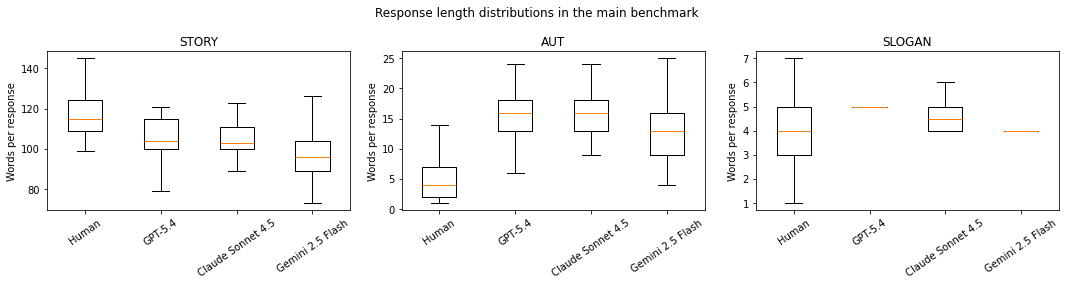

In [20]:
def plot_word_count_distributions(df: pd.DataFrame, save_path: Optional[Path] = None):
    task_order = ["story", "aut", "slogan"]
    label_order = ["Human", "GPT-5.4", "Claude Sonnet 4.5", "Gemini 2.5 Flash"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

    for ax, task in zip(axes, task_order):
        sub = df[df["task_family"] == task].copy()

        data = [
            sub[sub["model_label"] == label]["response_word_count"].dropna().values
            for label in label_order
            if label in set(sub["model_label"])
        ]
        labels = [
            label
            for label in label_order
            if label in set(sub["model_label"])
        ]

        ax.boxplot(data, tick_labels=labels, showfliers=False)
        ax.set_title(task.upper())
        ax.set_ylabel("Words per response")
        ax.tick_params(axis="x", rotation=35)

    fig.suptitle("Response length distributions in the main benchmark")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_word_count_distributions(
    main_plot_df,
    save_path=FIG_DIR / "main_benchmark_word_count_distributions.png",
)

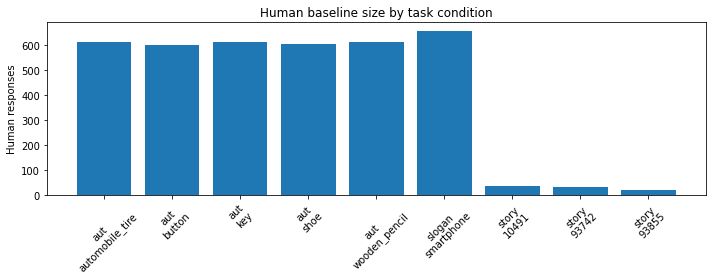

,task_family,condition_id,n_responses,n_unique_responses,n_participants
0,aut,automobile_tire,615,575,109
1,aut,button,603,583,109
2,aut,key,612,574,109
3,aut,shoe,604,532,109
4,aut,wooden_pencil,613,583,109
5,slogan,smartphone,659,650,95
6,story,10491,35,35,35
7,story,93742,32,32,32
8,story,93855,20,20,20


In [21]:
human_condition_counts = (
    human_standard_df
    .groupby(["task_family", "condition_id"], dropna=False)
    .agg(
        n_responses=("response_text", "size"),
        n_unique_responses=("response_text", "nunique"),
        n_participants=("participant_id", "nunique"),
    )
    .reset_index()
    .sort_values(["task_family", "condition_id"])
)

fig, ax = plt.subplots(figsize=(10, 4))

x_labels = human_condition_counts["task_family"] + "\n" + human_condition_counts["condition_id"]
ax.bar(x_labels, human_condition_counts["n_responses"])
ax.set_ylabel("Human responses")
ax.set_title("Human baseline size by task condition")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIG_DIR / "human_responses_by_condition.png", dpi=300, bbox_inches="tight")
plt.show()

human_condition_counts

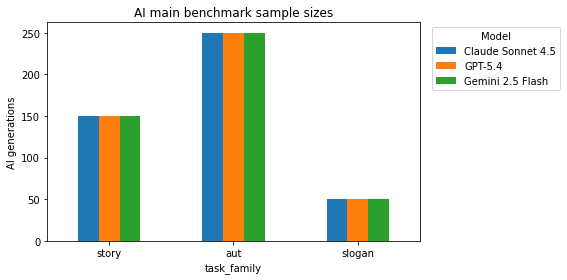

,task_family,model_label,n_generations
0,aut,Claude Sonnet 4.5,250
1,aut,GPT-5.4,250
2,aut,Gemini 2.5 Flash,250
3,slogan,Claude Sonnet 4.5,50
4,slogan,GPT-5.4,50
5,slogan,Gemini 2.5 Flash,50
6,story,Claude Sonnet 4.5,150
7,story,GPT-5.4,150
8,story,Gemini 2.5 Flash,150


In [22]:
ai_main_counts = (
    ai_main_df
    .merge(model_registry_df[["provider", "model", "model_label"]], on=["provider", "model"], how="left")
    .groupby(["task_family", "model_label"], dropna=False)
    .size()
    .reset_index(name="n_generations")
)

fig, ax = plt.subplots(figsize=(8, 4))

pivot = ai_main_counts.pivot(index="task_family", columns="model_label", values="n_generations").fillna(0)
pivot = pivot.loc[["story", "aut", "slogan"]]

pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("AI generations")
ax.set_title("AI main benchmark sample sizes")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "ai_main_generation_counts.png", dpi=300, bbox_inches="tight")
plt.show()

ai_main_counts

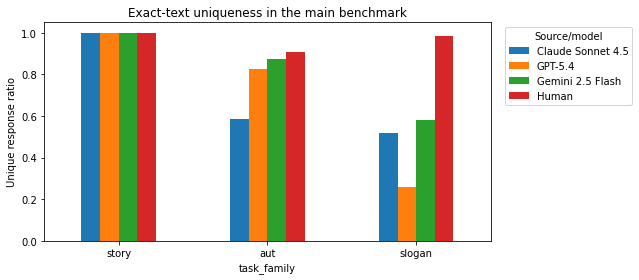

,task_family,model_label,n,n_unique,unique_ratio
0,aut,Claude Sonnet 4.5,250,146,0.584000
1,aut,GPT-5.4,250,206,0.824000
2,aut,Gemini 2.5 Flash,250,218,0.872000
3,aut,Human,3047,2764,0.907122
4,slogan,Claude Sonnet 4.5,50,26,0.520000
5,slogan,GPT-5.4,50,13,0.260000
6,slogan,Gemini 2.5 Flash,50,29,0.580000
7,slogan,Human,659,650,0.986343
8,story,Claude Sonnet 4.5,150,150,1.000000
9,story,GPT-5.4,150,150,1.000000


In [23]:
unique_ratio_table = (
    main_plot_df
    .groupby(["task_family", "model_label"], dropna=False)
    .agg(
        n=("response_text", "size"),
        n_unique=("response_text", "nunique"),
    )
    .reset_index()
)

unique_ratio_table["unique_ratio"] = unique_ratio_table["n_unique"] / unique_ratio_table["n"]

fig, ax = plt.subplots(figsize=(9, 4))

pivot = unique_ratio_table.pivot(index="task_family", columns="model_label", values="unique_ratio")
pivot = pivot.loc[["story", "aut", "slogan"]]

pivot.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Unique response ratio")
ax.set_title("Exact-text uniqueness in the main benchmark")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Source/model", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "main_benchmark_exact_text_unique_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

unique_ratio_table.to_csv(TABLE_DIR / "main_benchmark_exact_text_unique_ratio.csv", index=False)
unique_ratio_table

In [24]:
aut_bucket_summary = (
    human_aut_df
    .groupby(["condition_id", "bucket_id", "bucket_key"], dropna=False)
    .agg(
        n_ideas=("response_text", "size"),
        n_participants=("participant_id", "nunique"),
        example_idea=("response_text", "first"),
    )
    .reset_index()
    .sort_values(["condition_id", "n_ideas"], ascending=[True, False])
)

aut_bucket_summary.to_csv(TABLE_DIR / "human_aut_bucket_summary.csv", index=False)

print("AUT bucket summary shape:", aut_bucket_summary.shape)
aut_bucket_summary.head(30)

AUT bucket summary shape: (1142, 6)


,condition_id,bucket_id,bucket_key,n_ideas,n_participants,example_idea
6,automobile_tire,7,automobile_tire::7,57,57,Make a tire swing
23,automobile_tire,31,automobile_tire::31,35,34,Use them for mini raised garden beds
11,automobile_tire,12,automobile_tire::12,26,26,Seat for rolling down a hill
43,automobile_tire,54,automobile_tire::54,16,16,Basis for a picnic table
68,automobile_tire,91,automobile_tire::91,16,16,Weight for working out
16,automobile_tire,22,automobile_tire::22,14,13,use as a chair on ground add cushion to top
38,automobile_tire,47,automobile_tire::47,12,12,Use it in an obstacle course
51,automobile_tire,66,automobile_tire::66,11,11,Turn it into a large dog bed
12,automobile_tire,15,automobile_tire::15,10,10,as a tool for raising fire
48,automobile_tire,61,automobile_tire::61,10,10,Lay it flat and fill it with soil and make a garden out of them


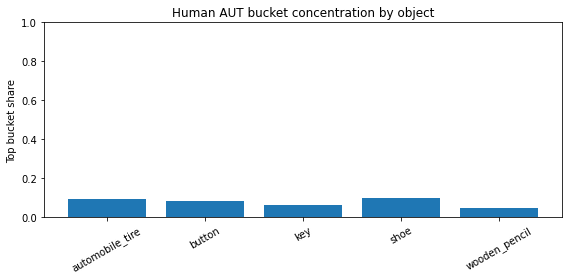

,condition_id,n_ideas,n_buckets,top_bucket_id,top_bucket_key,top_bucket_n,top_bucket_share
0,automobile_tire,615,262,7,automobile_tire::7,57,0.092683
1,button,603,237,3,button::3,52,0.086235
2,key,612,194,11,key::11,38,0.062092
3,shoe,604,207,18,shoe::18,59,0.097682
4,wooden_pencil,613,242,14,wooden_pencil::14,31,0.050571


In [25]:
aut_bucket_concentration = (
    human_aut_df
    .groupby("condition_id", dropna=False)
    .agg(
        n_ideas=("response_text", "size"),
        n_buckets=("bucket_key", "nunique"),
    )
    .reset_index()
)

# Top-bucket share per condition.
top_bucket_share = (
    human_aut_df
    .groupby(["condition_id", "bucket_id", "bucket_key"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["condition_id", "n"], ascending=[True, False])
    .groupby("condition_id", as_index=False)
    .first()
    .rename(columns={
        "n": "top_bucket_n",
        "bucket_id": "top_bucket_id",
        "bucket_key": "top_bucket_key",
    })
)

aut_bucket_concentration = aut_bucket_concentration.merge(
    top_bucket_share,
    on="condition_id",
    how="left",
)

aut_bucket_concentration["top_bucket_share"] = (
    aut_bucket_concentration["top_bucket_n"] / aut_bucket_concentration["n_ideas"]
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(aut_bucket_concentration["condition_id"], aut_bucket_concentration["top_bucket_share"])
ax.set_ylim(0, 1)
ax.set_ylabel("Top bucket share")
ax.set_title("Human AUT bucket concentration by object")
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(FIG_DIR / "human_aut_top_bucket_share.png", dpi=300, bbox_inches="tight")
plt.show()

aut_bucket_concentration.to_csv(TABLE_DIR / "human_aut_bucket_concentration.csv", index=False)
aut_bucket_concentration

In [26]:
robustness_design_summary = (
    ai_robustness_df
    .merge(model_registry_df[["provider", "model", "model_label"]], on=["provider", "model"], how="left")
    .groupby(["task_family", "model_label", "analysis_scenario_name", "temperature"], dropna=False)
    .agg(
        n_generations=("response_text", "size"),
        n_conditions=("condition_id", "nunique"),
        n_personas=("persona_id", lambda x: x.dropna().nunique()),
        mean_words=("response_word_count", "mean"),
        median_words=("response_word_count", "median"),
    )
    .reset_index()
    .sort_values(["task_family", "model_label", "analysis_scenario_name", "temperature"])
)

robustness_design_summary.to_csv(TABLE_DIR / "robustness_design_summary.csv", index=False)
robustness_design_summary

,task_family,model_label,analysis_scenario_name,temperature,n_generations,n_conditions,n_personas,mean_words,median_words
0,aut,Claude Sonnet 4.5,neutral_temperature_robustness,0.3,50,5,0,15.960000,16.5
1,aut,Claude Sonnet 4.5,neutral_temperature_robustness,0.7,50,5,0,14.500000,14.5
2,aut,Claude Sonnet 4.5,personality_grid,0.3,1600,5,32,17.376875,17.0
3,aut,Claude Sonnet 4.5,personality_grid,0.7,1600,5,32,17.619375,17.0
4,aut,Claude Sonnet 4.5,personality_grid,1.0,1600,5,32,17.610625,17.0
5,aut,GPT-5.4,neutral_temperature_robustness,0.7,50,5,0,15.580000,15.5
6,aut,GPT-5.4,neutral_temperature_robustness,1.3,50,5,0,15.240000,15.0
7,aut,GPT-5.4,personality_grid,0.7,1600,5,32,17.905000,18.0
8,aut,GPT-5.4,personality_grid,1.0,1600,5,32,18.148750,18.0
9,aut,GPT-5.4,personality_grid,1.3,1600,5,32,18.226250,18.0


In [27]:
STANDARDIZED_DIR = ANALYSIS_DIR / "standardized_loaded_data"
STANDARDIZED_DIR.mkdir(parents=True, exist_ok=True)

# Re-export human AUT file with bucket_key for downstream robustness kernels.
human_aut_with_bucket_key_path_pkl = STANDARDIZED_DIR / "human_aut_with_bucket_key.pkl"
human_aut_with_bucket_key_path_csv = STANDARDIZED_DIR / "human_aut_with_bucket_key.csv"

human_aut_df.to_pickle(human_aut_with_bucket_key_path_pkl)
human_aut_df.to_csv(human_aut_with_bucket_key_path_csv, index=False)

# Re-export all standardized data.
human_standard_df.to_pickle(STANDARDIZED_DIR / "human_standard_all_tasks.pkl")
human_standard_df.to_csv(STANDARDIZED_DIR / "human_standard_all_tasks.csv", index=False)

ai_standard_df.to_pickle(STANDARDIZED_DIR / "ai_standard_all_tasks_success_only.pkl")
ai_standard_df.to_csv(STANDARDIZED_DIR / "ai_standard_all_tasks_success_only.csv", index=False)

ai_main_df.to_pickle(STANDARDIZED_DIR / "ai_main_benchmark.pkl")
ai_main_df.to_csv(STANDARDIZED_DIR / "ai_main_benchmark.csv", index=False)

ai_robustness_df.to_pickle(STANDARDIZED_DIR / "ai_robustness_all.pkl")
ai_robustness_df.to_csv(STANDARDIZED_DIR / "ai_robustness_all.csv", index=False)

print("Saved standardized data to:", STANDARDIZED_DIR)
print("Human AUT with bucket_key:", human_aut_with_bucket_key_path_pkl)
print("Human AUT with bucket_key:", human_aut_with_bucket_key_path_csv)

assert "bucket_key" in human_aut_df.columns
assert "bucket_key" in human_standard_df.columns
assert human_standard_df.query("task_family == 'aut'")["bucket_key"].notna().all()

print("Re-export checks passed.")

Saved standardized data to: analysis_outputs/standardized_loaded_data
Human AUT with bucket_key: analysis_outputs/standardized_loaded_data/human_aut_with_bucket_key.pkl
Human AUT with bucket_key: analysis_outputs/standardized_loaded_data/human_aut_with_bucket_key.csv
Re-export checks passed.


In [28]:
print("=" * 100)
print("HUMAN DATA")
print("=" * 100)
display(human_task_summary)
display(task_condition_table)

print("=" * 100)
print("AI MAIN BENCHMARK")
print("=" * 100)
display(ai_main_task_summary)
display(main_sample_size_table)

print("=" * 100)
print("AI ROBUSTNESS")
print("=" * 100)
display(robustness_design_summary)

print("=" * 100)
print("Saved tables")
print("=" * 100)
for p in sorted(TABLE_DIR.glob("*.csv")):
    print(p)

print("=" * 100)
print("Saved figures")
print("=" * 100)
for p in sorted(FIG_DIR.glob("*.png")):
    print(p)

HUMAN DATA


,task_family,n_human_responses,n_human_unique_responses,n_human_conditions,n_human_participants_or_units,human_mean_words,human_median_words,human_min_words,human_max_words
0,aut,3047,2764,5,109,5.306859,4.0,1,33
1,slogan,659,650,1,95,4.176024,4.0,1,7
2,story,87,87,3,87,123.367816,115.0,99,268


,task_family,condition_id,condition_label,prompt_or_object,n_human_responses,n_human_unique_responses,n_human_participants_or_units,human_mean_words,human_median_words,human_min_words,human_max_words
0,aut,automobile_tire,Automobile tire,automobile tire,615,575,109,5.986992,5.0,1,28
1,aut,button,Button,button,603,583,109,5.296849,4.0,1,28
2,aut,key,Key,key,612,574,109,5.558824,4.0,1,33
3,aut,shoe,Shoe,shoe,604,532,109,4.114238,3.0,1,27
4,aut,wooden_pencil,Wooden pencil,wooden pencil,613,583,109,5.557912,4.0,1,30
5,slogan,smartphone,Smartphone,smartphone,659,650,95,4.176024,4.0,1,7
6,story,10491,A short Horror story . Something to chill the bones in one hundred words or less .,A short Horror story . Something to chill the bones in one hundred words or less .,35,35,35,121.200000,111.0,100,241
7,story,93742,[ FF ] 100 Words or Less - The parachute is n't opening up,[ FF ] 100 Words or Less - The parachute is n't opening up,32,32,32,127.281250,115.5,99,268
8,story,93855,[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,[ FF ] Describe 100 years of a character 's life in 10 words . Then describe the last 10 seconds of their life in 100 words .,20,20,20,120.900000,117.0,106,148


AI MAIN BENCHMARK


,task_family,provider,model,n_ai_main,n_ai_unique_main,n_ai_conditions,ai_mean_words,ai_median_words,ai_min_words,ai_max_words
0,aut,anthropic,claude-sonnet-4-5,250,146,5,15.556000,16.0,9,26
1,aut,gemini,gemini-2.5-flash,250,218,5,12.636000,13.0,4,32
2,aut,openai,gpt-5.4,250,206,5,15.600000,16.0,6,24
3,slogan,anthropic,claude-sonnet-4-5,50,26,1,4.700000,4.5,4,6
4,slogan,gemini,gemini-2.5-flash,50,29,1,3.840000,4.0,3,5
5,slogan,openai,gpt-5.4,50,13,1,4.860000,5.0,3,5
6,story,anthropic,claude-sonnet-4-5,150,150,1,105.020000,103.0,89,123
7,story,gemini,gemini-2.5-flash,150,150,1,97.380000,96.0,62,134
8,story,openai,gpt-5.4,150,150,1,106.206667,104.0,79,121


,task_family,provider,model,condition_id,n_ai_main,n_ai_unique_main,mean_ai_words,median_ai_words,n_human_responses,n_human_unique_responses,n_human_participants_or_units,human_mean_words,human_median_words
0,aut,anthropic,claude-sonnet-4-5,automobile_tire,50,10,9.780000,9.0,615.0,575.0,109.0,5.986992,5.0
1,aut,anthropic,claude-sonnet-4-5,button,50,40,19.360000,21.0,603.0,583.0,109.0,5.296849,4.0
2,aut,anthropic,claude-sonnet-4-5,key,50,27,16.940000,17.0,612.0,574.0,109.0,5.558824,4.0
3,aut,anthropic,claude-sonnet-4-5,shoe,50,37,15.780000,15.0,604.0,532.0,109.0,4.114238,3.0
4,aut,anthropic,claude-sonnet-4-5,wooden_pencil,50,32,15.920000,16.0,613.0,583.0,109.0,5.557912,4.0
5,aut,gemini,gemini-2.5-flash,automobile_tire,50,44,12.920000,11.5,615.0,575.0,109.0,5.986992,5.0
6,aut,gemini,gemini-2.5-flash,button,50,48,15.080000,14.0,603.0,583.0,109.0,5.296849,4.0
7,aut,gemini,gemini-2.5-flash,key,50,45,9.780000,9.0,612.0,574.0,109.0,5.558824,4.0
8,aut,gemini,gemini-2.5-flash,shoe,50,37,14.540000,15.0,604.0,532.0,109.0,4.114238,3.0
9,aut,gemini,gemini-2.5-flash,wooden_pencil,50,44,10.860000,10.0,613.0,583.0,109.0,5.557912,4.0


AI ROBUSTNESS


,task_family,model_label,analysis_scenario_name,temperature,n_generations,n_conditions,n_personas,mean_words,median_words
0,aut,Claude Sonnet 4.5,neutral_temperature_robustness,0.3,50,5,0,15.960000,16.5
1,aut,Claude Sonnet 4.5,neutral_temperature_robustness,0.7,50,5,0,14.500000,14.5
2,aut,Claude Sonnet 4.5,personality_grid,0.3,1600,5,32,17.376875,17.0
3,aut,Claude Sonnet 4.5,personality_grid,0.7,1600,5,32,17.619375,17.0
4,aut,Claude Sonnet 4.5,personality_grid,1.0,1600,5,32,17.610625,17.0
5,aut,GPT-5.4,neutral_temperature_robustness,0.7,50,5,0,15.580000,15.5
6,aut,GPT-5.4,neutral_temperature_robustness,1.3,50,5,0,15.240000,15.0
7,aut,GPT-5.4,personality_grid,0.7,1600,5,32,17.905000,18.0
8,aut,GPT-5.4,personality_grid,1.0,1600,5,32,18.148750,18.0
9,aut,GPT-5.4,personality_grid,1.3,1600,5,32,18.226250,18.0


Saved tables
analysis_outputs/tables/ai_generation_design_summary.csv
analysis_outputs/tables/ai_main_task_level_summary.csv
analysis_outputs/tables/human_aut_bucket_concentration.csv
analysis_outputs/tables/human_aut_bucket_summary.csv
analysis_outputs/tables/human_aut_ideas_per_participant_condition.csv
analysis_outputs/tables/human_slogans_per_participant.csv
analysis_outputs/tables/human_task_level_summary.csv
analysis_outputs/tables/main_benchmark_exact_text_unique_ratio.csv
analysis_outputs/tables/main_benchmark_sample_sizes.csv
analysis_outputs/tables/robustness_design_summary.csv
analysis_outputs/tables/robustness_sample_sizes.csv
analysis_outputs/tables/task_condition_human_summary.csv
Saved figures
analysis_outputs/figures/ai_main_generation_counts.png
analysis_outputs/figures/human_aut_top_bucket_share.png
analysis_outputs/figures/human_responses_by_condition.png
analysis_outputs/figures/main_benchmark_exact_text_unique_ratio.png
analysis_outputs/figures/main_benchmark_word_